1\. **Radioactive decay chain**

${\rm Tl}^{208}$ decays to ${\rm Pb}^{208}$ with a half-lieve of 3.052 minutes. Suppose to start with a sample of 1000 Thallium atoms and 0 of Lead atoms.

* Take steps in time of 1 second and at each time-step decide whether each Tl atom has decayed or not, accordingly to the probability $p(t)=1-2^{-t/\tau}$. Subtract the total number of Tl atoms that decayed at each step from the Tl sample and add them to the Lead one. Plot the evolution of the two sets as a function of time  
* Repeat the exercise by means of the inverse transform method: draw 1000 random numbers from the non-uniform probability distribution $p(t)=2^{-t/\tau}\frac{\ln 2}{\tau}$ to represent the times of decay of the 1000 Tl atoms. Make a plot showing the number of atoms that have not decayed as a function of time

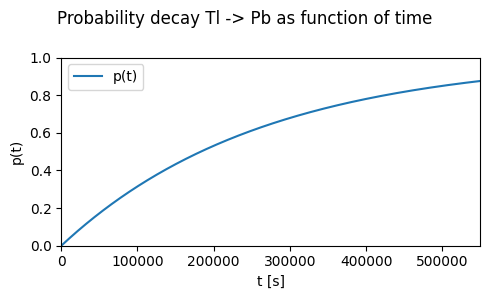

In [1]:
import numpy as np
import matplotlib.pyplot as plt

tau = 3052*60

def p(t):
    return 1 - pow(2, -t/tau)

t_steps = np.arange(0, 3 * tau, 1)

plt.figure(figsize=(5,3))
plt.plot(t_steps, p(t_steps), label ='p(t)')
plt.suptitle("Probability decay Tl -> Pb as function of time")
plt.xlabel('t [s]')
plt.xlim([0, 3*tau])
plt.ylim([0,1])
plt.ylabel('p(t)')
plt.legend()
plt.tight_layout()
plt.show()

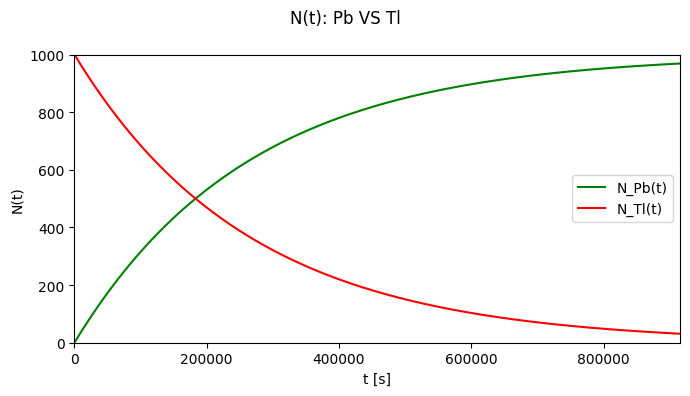

In [2]:
N0 = 1000
Pb = 0
# we have to sample values from the previous distribution

N_Pb = lambda t : N0 * p(t)
N_Tl = lambda t : N0 * (1 - p(t))

t_steps = np.arange(0, 5 * tau, 1)

plt.figure(figsize=(7,4))
plt.plot(t_steps, N_Pb(t_steps), label ='N_Pb(t)', color = 'green')
plt.plot(t_steps, N_Tl(t_steps), label ='N_Tl(t)', color = 'red')
plt.suptitle("N(t): Pb VS Tl")
plt.xlabel('t [s]')
plt.ylim([0, N0])
plt.xlim([0, 5*tau])
plt.ylabel('N(t)')
plt.legend()
plt.tight_layout()
plt.show()

* Repeat the exercise by means of the inverse transform method: draw 1000 random numbers from the non-uniform probability distribution $p(t)=2^{-t/\tau}\frac{\ln 2}{\tau}$ to represent the times of decay of the 1000 Tl atoms. Make a plot showing the number of atoms that have not decayed as a function of time

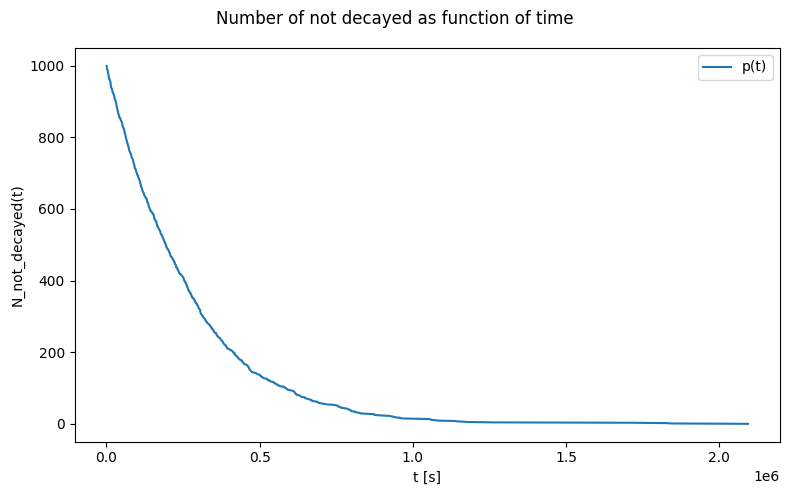

In [3]:
CDF = lambda z : - tau * np.log2(1 - z)
u = np.random.random(1000)

t_dec = np.sort(CDF(u))
N_ndec = np.arange(N0 - 1, -1, -1)

plt.figure(figsize=(8,5))
plt.plot(t_dec, N_ndec, label ='p(t)')
plt.suptitle("Number of not decayed as function of time")
plt.xlabel('t [s]')
plt.ylabel('N_not_decayed(t)')
plt.legend()
plt.tight_layout()
plt.show()

2\. **Rutherford Scattering**

The scattering angle $\theta$ of $\alpha$ particles hitting a positively charged nucleus of a Gold atom ($Z=79$) follows the rule:

$$
\tan{\frac{1}{2} \theta} = \frac{Z e^2} {2\pi \epsilon_0 E b}
$$

where $E=7.7$ MeV and $b$ beam is the impact parameter. The beam is represented by a 2D gaussian distribution with $\sigma=a_0/100$ for both coordinates ($a_0$ being the Bohr radius). Assume 1 million $\alpha$ particles are shot on the gold atom.

Computing the fraction of particles that "bounce back",i.e. those particle whose scattering angle is greater than $\pi/2$ (which set a condition on the impact parameter $b$)

In [4]:
import scipy.constants as const
from scipy.constants import physical_constants as pc

a0 = pc['Bohr radius'][0] # Bohr radius
eps0 = const.epsilon_0  # Vacuum permittivity
e = const.e  #Charge
Z = 79
E = 7.7 * 10 ** 6 * e # in Joule

c = (Z * e * e) / ( 2 * np.pi * eps0 * E ) # minimum b to get scattered backwards (np.tan(np.pi / 4) = 1) 

In [5]:
import numpy.random as npr

N_alpha = 10**6
cov = np.array([[(a0/100)**2, 0], [0, (a0/100)**2]])
x = npr.multivariate_normal([0,0], cov, size=N_alpha)

/tmp/ipykernel_29083/1864285690.py:14: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


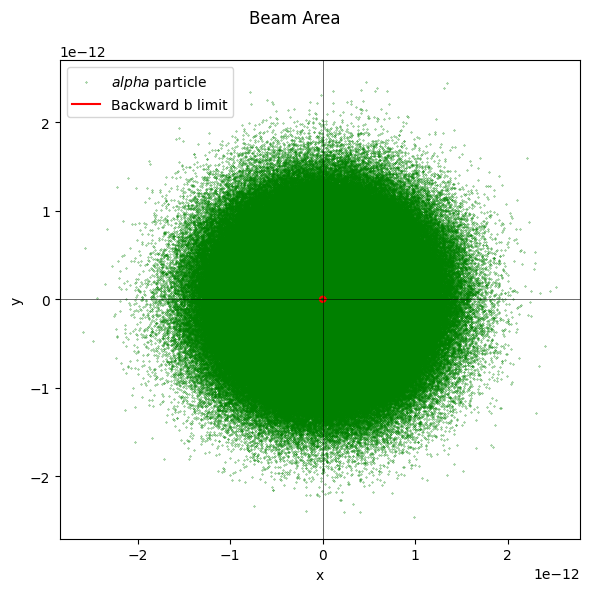

In [6]:
plt.figure(figsize=(6,6))
plt.suptitle('Beam Area')

theta = np.linspace(0, 2*np.pi, 100)

plt.scatter(x[:,0], x[:,1], color = 'g', marker = '.', s = 0.3, label='$alpha$ particle') # beam
plt.plot(c * np.cos(theta), c * np.sin(theta), color='r', label='Backward b limit') # cannot see it

plt.xlabel('x')
plt.ylabel('y')
plt.axhline(0, color='black', lw=0.4)
plt.axvline(0, color='black', lw=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
mask = (np.sqrt(x[:,0]**2 + x[:,1]**2) < c) # the one with radius less then limit
print(f"Fraction of Bounced Backward particles:= {(np.sum(mask) / N_alpha):.4f} ")

Fraction of Bounced Backward particles:= 0.0015 


3\. **Monte Carlo integration: hit/miss vs mean value method**

Consider the function 

$$f(x) =\sin^2{\frac{1}{x(2-x)}}$$

* Compute the integral of $f(x)$ between 0 and 2 with the hit/miss method. Evaluate the error of your estimate
* Repeat the integral with the mean value method. Evaluate the error and compare it with the previous one

In [8]:
npr.seed(123)

f = lambda x : np.sin( 1 / (x * (2 - x))) ** 2

N = 1000000
x, y = npr.random(N)*2, npr.random(N) # x in [0,2]

# Hit or miss in [0,2]x[0,1]
mask = (y < f(x))
k = np.sum(mask)
A = 2*1

I1 = A * k / N

print(f"Integral estimation I = A * k / N = {I1:.4f}")

Integral estimation I = A * k / N = 1.4508


In [9]:
f_mean = np.mean(f(x))
a, b = 0, 2

I2 = (b-a) * f_mean
sigma = (b - a) * np.std(f(x)) / np.sqrt(N)

print(f"Integral estimation I = (b-a)*<f> = {I2:.4f} \u00B1 {sigma:.4f}")

Integral estimation I = (b-a)*<f> = 1.4518 ± 0.0005


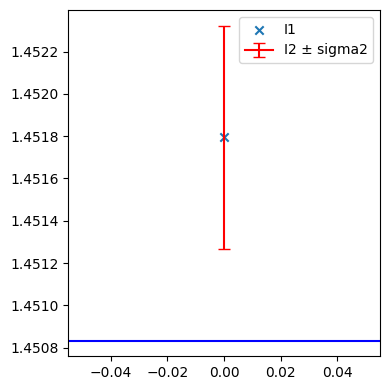

In [10]:
plt.figure(figsize=(4,4))
plt.errorbar(0, I2, yerr=sigma, capsize=4, color = 'r', label='I2 \u00B1 sigma2')
plt.scatter(0, I2, marker='x', label='I1')
plt.axhline(I1, color='b')
plt.legend()
plt.tight_layout()
plt.show()

4\. **Monte Carlo integration in high dimension**

* Start of by computing the area of a circle of unit radius, by integrating the function 

$$
f(x,y)=
\left\{
\begin{array}{ll}
      1 & x^2+y^2\le 1 \\
      0 & {\rm elsewhere}
\end{array} 
\right.
$$

* Generalize the result for a 10D sphere



In [11]:
def f(x,y):
    r2 = x**2 + y**2
    if (r2 <= 1):
        return 1
    else:
        return 0
N = 100000
f_mean = 0
for i in range(N):
    x, y = npr.random()*2 - 1, npr.random()*2 -1 # [-1,1]
    f_mean += f(x, y) / N
A = 4 # 2 * 2

print(f"Area of the unit circle := {np.pi}")
print(f"Area of the unit circle computed := {A * f_mean}")

Area of the unit circle := 3.141592653589793
Area of the unit circle computed := 3.1473199999962156


In [12]:
# We gen to dim 10
from scipy import special


def f(v):
    r2 = np.sum([x**2 for x in v]) # 10 dim radius
    if (r2 <= 1):
        return 1
    else:
        return 0
        
N = 1000000
f_mean = 0
v = np.zeros(10)
for i in range(N):
    for i in range(10):
        v[i] = npr.random() * 2 - 1 # in [-1,1]
    f_mean += f(v) / N
A = 2**10 # 2 * 2

print(f"Measure of the 10D unit circle computed := {pow(np.pi, int(10/2)) / special.gamma(10/2 + 1)}")
print(f"Measure of the 10D unit circle computed := {A * f_mean}")
# good exstimation method but in 10D a lot of points are needed

Measure of the 10D unit circle computed := 2.550164039877345
Measure of the 10D unit circle computed := 2.5456640000000057


5\. **Monte Carlo integration with importance sampling** 

Calculate the value of the integral:

$$
I=\int_0^1 \frac{x^{-1/2}}{e^x+1} dx
$$

using the importance sampling method with $w(x)=1/\sqrt{x}$. You should get a result about 0.84

In [13]:
f = lambda x : 1 / (np.sqrt(x) * (1 + np.exp(x)))
w = lambda x : 1 / np.sqrt(x)

int_w = 2 # integral of the 1 / sq(x)
N = 1000000
# in this case the mean value has to be calculated considering the rv distributed according to w(x) probability distribution
# in order to sample according to w(x), we use the inverse transform method

pw = lambda x : 1 / ( 2 * np.sqrt(x) ) # pdf normalized in [0,1]
icdf_pw = lambda z : pow(z, 2)

z = npr.random(N)
f_on_w_mean = np.mean( f( icdf_pw(z) ) / w( icdf_pw(z) ) )

I = f_on_w_mean * int_w

print(f"Integral with MonteCarlo estimation: {I:.3f}")

Integral with MonteCarlo estimation: 0.839
